# 02 · Modelado de propensión a compra

**Qué hace este notebook (corre LOCAL, sobre el snapshot de la Gold):**
baseline → GBM → calibración → umbral → evaluación. El clustering y el cruce
clasificador × clustering van en un notebook aparte. MLflow + scoring batch se
hacen al final **en Databricks** (no aquí).

**Decisiones:**
- **Métrica:** PR-AUC + calibración (Brier). *Nunca* accuracy (evento raro ~6%).
- **Cuarentena anti-fuga:** se excluye 15–17 nov (`label_window_corrupt==1`), train *y* test.
- **Split temporal — Opción C:** train = Oct + Nov ≤ 23 · test = Nov 24–30 (*out-of-time*, mismo régimen).
- **Estratificación:** SOLO en la CV interna (`StratifiedKFold`), nunca en la frontera temporal (eso sería fuga).
- **`is_black_friday`:** solo para estratificar la evaluación, **no** es feature.
- **`sin_navegacion_previa`:** por defecto se MANTIENE como feature (Opción A); abajo puedes cambiarlo.
- **Desbalance:** `class_weight`/`scale_pos_weight` **dentro** del fit, nunca tocando el test.


## 0. Entorno

Si te falta alguna librería, descomenta y corre la celda de instalación una vez.

In [1]:
# %pip install pandas pyarrow numpy scikit-learn imbalanced-learn lightgbm optuna matplotlib
# (shap es opcional, solo si quieres esa capa extra de diagnóstico:)
# %pip install shap

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

# ── Ruta robusta: sube hasta encontrar .git, funciona desde workspace root
#    o desde notebooks/modeling/ ────────────────────────────────────────────
def _repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / ".git").exists():
            return p
    return start

REPO_ROOT = _repo_root(Path.cwd())
DATA_DIR  = REPO_ROOT / "data" / "gold_snapshot"
print(f"Repo : {REPO_ROOT}")
print(f"Data : {DATA_DIR} | existe: {DATA_DIR.exists()}")

# ── Parámetros del split (Opción C) ───────────────────────────────────────
CORTE_TRAIN = "2019-11-23"
TEST_INI    = "2019-11-24"
TEST_FIN    = "2019-11-30"

# ── Modo de iteración ──────────────────────────────────────────────────────
FRAC_ITERACION  = 0.10   # fracción del train para baseline/Optuna
N_TRIALS_OPTUNA = 20     # súbelo (≥50) para el fit final
MANTENER_SIN_NAV = True  # True = sin_navegacion_previa como feature (Opción A)

Repo : c:\Users\Usuario\Repositorios git\proyecto-integrador-g8
Data : c:\Users\Usuario\Repositorios git\proyecto-integrador-g8\data\gold_snapshot | existe: True


## 1. Carga del snapshot Gold

La Gold cargó **completa: 22.99M sesiones × 22 columnas** — grano correcto (filas = sesiones únicas), tasa de compra 0.061 y ~4.7 GB en memoria. El *downcast* de tipos lleva el tamaño hasta ahí sin pérdida de precisión en las features numéricas.

In [3]:
gold = pd.read_parquet(DATA_DIR)
print("Forma cruda:", gold.shape)

# Downcast para ahorrar memoria (numéricos) y normalizar booleanos/fecha
gold["target_purchase"] = gold["target_purchase"].astype("int8")
for c in ["is_weekend", "is_black_friday", "label_window_corrupt"]:
    gold[c] = gold[c].astype("int8")
gold["sin_navegacion_previa"] = gold["sin_navegacion_previa"].astype("int8")
gold["session_date"] = pd.to_datetime(gold["session_date"])
for c in gold.select_dtypes("float64").columns:
    gold[c] = pd.to_numeric(gold[c], downcast="float")
for c in gold.select_dtypes("int64").columns:
    gold[c] = pd.to_numeric(gold[c], downcast="integer")

print("\nColumnas:", list(gold.columns))
print("\nMemoria: %.2f GB" % (gold.memory_usage(deep=True).sum()/1e9))

# Sanity check: grano y tasa de etiqueta (esperado ~22.99M filas, tasa ~0.061)
print("\nFilas:", f"{len(gold):,}",
      "| sesiones únicas:", f"{gold['user_session'].nunique():,}")
print("Tasa target_purchase (FULL):", round(gold["target_purchase"].mean(), 4))

Forma cruda: (22995676, 22)

Columnas: ['user_session', 'target_purchase', 'user_id', 'total_views', 'distinct_products_viewed', 'brands_compared', 'categories_explored', 'categories_explored_cid', 'browsing_duration_sec', 'avg_price_viewed', 'max_price_viewed', 'electronics_view_share', 'sin_navegacion_previa', 'session_date', 'session_hour', 'day_of_week', 'is_weekend', 'is_black_friday', 'label_window_corrupt', 'revisit_intensity', 'views_per_minute', 'avg_inter_event_sec']

Memoria: 4.69 GB

Filas: 22,995,676 | sesiones únicas: 22,995,676
Tasa target_purchase (FULL): 0.061


## 2. Cuarentena anti-fuga (15–17 nov)

Se excluyen **2.72M sesiones (~12%)** de la ventana 15–17 nov: la etiqueta `purchase` está corrupta en ese periodo (15-nov: ~467k carritos, 0 compras; backlog volcado el 16–17). No es una decisión del split — es integridad de etiqueta, aplicada a train *y* test por igual.

> La tasa de compra queda en **0.0589** — la "tasa honesta" que reemplaza al 0.061 de la carga completa. Todo lo que sigue (split, modelo, evaluación) trabaja sobre esta base limpia.

In [4]:
n0 = len(gold)
gold = gold[gold["label_window_corrupt"] == 0].copy()
print(f"Excluidas por cuarentena 15–17 nov: {n0 - len(gold):,}")
print(f"Filas tras cuarentena: {len(gold):,} | tasa: {gold['target_purchase'].mean():.4f}")

Excluidas por cuarentena 15–17 nov: 2,725,198
Filas tras cuarentena: 20,270,478 | tasa: 0.0589


# 3. Split Temporal: Opción C

**Estructura del Dataset:**
* **Train:** 17.53M sesiones (1-oct al 23-nov) | Tasa de conversión: **5.94%**
* **Test:** 2.74M sesiones (24-nov al 30-nov) | Tasa de conversión: **5.60%**

La diferencia en la tasa de conversión entre ambos conjuntos es de apenas **5.8%**, lo que demuestra que train y test comparten el mismo régimen operativo. Esto garantiza una correcta **calibración de las probabilidades**. Debido a que el **30.6% del test** se concentra en el Black Friday (29–30 de noviembre), los resultados se reportarán desagregados (con y sin BF).


### Justificación Técnica y de Negocio (Por qué Opción C)

1. **Mitigación del Concept Drift:** La conversión por sesión decae de octubre (~6.8%) a inicios de noviembre (~5.0%). Un split que entrene solo en octubre (Opción A) dejaría al modelo descalibrado. Al incluir noviembre en Train, el modelo captura la deriva de la conversión y aprende el régimen real bajo el cual será evaluado.
2. **Estabilidad de Features:** La distribución de precios es consistente entre ventanas ($\text{PSI} \approx 0$), confirmando que el *drift* es del comportamiento del *target* y no de la escala de las variables clave.
3. **Réplica del Escenario de Producción:** Se rechaza el split aleatorio tradicional. El split temporal respeta la consistencia cronológica del negocio (entrenar con el pasado para predecir el futuro) y **evita la fuga de datos (data leakage) a nivel de usuario**, impidiendo que sesiones del mismo cliente se repartan entre ambos conjuntos.


### Invariantes del Diseño Experimental

* **Exclusión de la Ventana Corrupta (15–17 de noviembre):** Se eliminan por completo las sesiones donde `label_window_corrupt == 1` (ej. 467k carritos con 0 compras el 15-nov). **No se utiliza una variable bandera (*flag*)** para absorber este comportamiento, ya que el fallo radica en la corrupción del *target* (falsos negativos). Mantener estas filas sesgaría el aprendizaje en Train y penalizaría artificialmente la evaluación en Test al contrastar predicciones correctas contra etiquetas falsas. Además, este *flag* no existirá en producción.
* **Estrategia de Validación:** Se aplica `StratifiedKFold` **únicamente en la validación cruzada interna del Train** para asegurar la representatividad de la clase minoritaria (~6%). Jamás se estratifica la frontera temporal para evitar el anacronismo de los datos.
* **Evaluación de Atípicos (Black Friday):** El comportamiento extremo de BF es real y válido, por lo que se mantiene en el Test. La variable `is_black_friday` se usará exclusivamente como segmentador en la evaluación pos-modelado para reportar métricas con y sin este evento, nunca como *feature*.
* **Métricas de Rendimiento:** Se opta estrictamente por **PR-AUC** (debido al desbalance de clases) y **Brier Score** (para medir la calidad de la calibración de probabilidad). Se descarta el uso de *Accuracy*.


### Caveat Abierto (Riesgo Técnico)
Se identificó un incremento abrupto en el volumen de eventos `cart` durante noviembre. Se encuentra bajo validación si esto responde a un cambio genuino en el comportamiento del usuario o a una modificación en el protocolo de medición del *pipeline* de datos. Si se confirma lo segundo, se documentará como una limitación en la defensa, aunque no altera la estructura del split propuesto.

In [5]:
# Verificar que la cuarentena ya fue aplicada sobre gold antes de llegar aquí
assert (gold["label_window_corrupt"] == 0).all(), \
    "ERROR: quedan filas con label_window_corrupt==1. Correr la celda de cuarentena antes del split."

corte = pd.Timestamp(CORTE_TRAIN)
ini,  fin = pd.Timestamp(TEST_INI), pd.Timestamp(TEST_FIN)

mask_train = gold["session_date"] <= corte
mask_test  = (gold["session_date"] >= ini) & (gold["session_date"] <= fin)

train = gold[mask_train].copy()
test  = gold[mask_test].copy()

print(f"TRAIN: {len(train):,} filas | {train['session_date'].min().date()} → "
      f"{train['session_date'].max().date()} | tasa {train['target_purchase'].mean():.4f}")
print(f"TEST : {len(test):,} filas  | {test['session_date'].min().date()} → "
      f"{test['session_date'].max().date()} | tasa {test['target_purchase'].mean():.4f}")

brecha = abs(train["target_purchase"].mean() - test["target_purchase"].mean()) \
         / train["target_purchase"].mean() * 100
print(f"Brecha de tasa train↔test: {brecha:.1f}%  "
      f"({'SANO — mismo régimen' if brecha < 10 else '⚠ revisar corte'})")

# Máscara BF (29 y 30-nov) — solo para estratificar la evaluación, no como feature.
# is_black_friday en la Gold solo marca el 29; la fecha captura ambos días.
bf_window = test["session_date"].isin(
    [pd.Timestamp("2019-11-29"), pd.Timestamp("2019-11-30")]).values
print(f"\nFilas BF (29–30 nov) en test : {bf_window.sum():,}  ({bf_window.mean()*100:.1f}%)")

TRAIN: 17,526,578 filas | 2019-10-01 → 2019-11-23 | tasa 0.0594
TEST : 2,743,900 filas  | 2019-11-24 → 2019-11-30 | tasa 0.0560
Brecha de tasa train↔test: 5.8%  (SANO — mismo régimen)

Filas BF (29–30 nov) en test : 838,543  (30.6%)


## 4. X/Y y selección de features

Quedan **17 features**. Se excluyen los identificadores (`user_session`, `user_id`), el target, `session_date` (solo para el split), `is_black_friday` (solo para estratificar la evaluación) y label_window_corrupt (ya usada en la cuarentena). `session_hour` entra como `hour_sin`/`hour_cos`(codificación cíclica, para que las 23h y las 0h queden "cerca").  

¿Por qué se quitan `user_id` y `user_session` si parecería que la "continuidad" de una persona importa? Porque son **etiquetas de identidad, no comportamiento:** `user_session` es único en cada fila (no generaliza nada) y usar user_id sería "memorizar personas" (el modelo no sabría qué hacer con un usuario nuevo). Pero quitar el identificador no quita la información de interés repetido:

- Si alguien insiste en el mismo producto dentro de la visita, eso sí está capturado: `revisit_intensity` mide cuánto se re-miran los mismos productos (relación entre `total_views` y `distinct_products_viewed`), y `views_per_minute` la intensidad. Ese tipo de "estoy muy interesada en esto" ya entra al modelo.
- Lo que no se captura es la historia entre sesiones distintas (volver mañana a ver lo mismo). Es una decisión consciente de alcance: el EDA mostró que la compra se decide rapidísimo y dentro de la misma sesión (mediana 2.2 min, 77% en menos de 5), y la intervención de negocio es inmediata/en pantalla durante la visita. Modelar por sesión encaja con esa acción y evita riesgos de fuga temporal. La continuidad entre sesiones queda como extensión futura (features de historia de usuario) y se conecta con la palanca de recurrentes del A/B.

In [6]:
TARGET   = "target_purchase"
ID_COLS  = ["user_session", "user_id"]
EXCLUIR  = ID_COLS + [TARGET, "session_date", "is_black_friday", "label_window_corrupt"]

def add_cyclic_hour(df):
    df = df.copy()
    df["hour_sin"] = np.sin(2*np.pi*df["session_hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["session_hour"]/24)
    return df.drop(columns=["session_hour"])

train = add_cyclic_hour(train)
test  = add_cyclic_hour(test)

FEATURES = [c for c in train.columns if c not in EXCLUIR]
if not MANTENER_SIN_NAV:
    FEATURES = [c for c in FEATURES if c != "sin_navegacion_previa"]

print(f"{len(FEATURES)} features:\n", FEATURES)

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

17 features:
 ['total_views', 'distinct_products_viewed', 'brands_compared', 'categories_explored', 'categories_explored_cid', 'browsing_duration_sec', 'avg_price_viewed', 'max_price_viewed', 'electronics_view_share', 'sin_navegacion_previa', 'day_of_week', 'is_weekend', 'revisit_intensity', 'views_per_minute', 'avg_inter_event_sec', 'hour_sin', 'hour_cos']


## 5. Muestra estratificada para iterar

Para baseline y Optuna se usa el **10% del train** (1.75M filas), con la tasa de positivos preservada (0.0594). Esto reduce el tiempo de cada trial de Optuna en ~10× sin sacrificar representatividad. El **fit final** usa el train completo (17.53M).

In [7]:
from sklearn.model_selection import train_test_split
if FRAC_ITERACION < 1.0:
    X_it, _, y_it, _ = train_test_split(
        X_train, y_train, train_size=FRAC_ITERACION,
        stratify=y_train, random_state=RANDOM_STATE)
else:
    X_it, y_it = X_train, y_train
print(f"Muestra de iteración: {len(X_it):,} filas | tasa {y_it.mean():.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Muestra de iteración: 1,752,657 filas | tasa 0.0594


## 6. Baseline trivial — la trampa del accuracy

El modelo "nadie compra" logra **94.4% de accuracy pero PR-AUC 0.056** (= la tasa base): no detecta ni una compra. Es la demostración de por qué el accuracy miente con clases desbalanceadas. **Cualquier modelo serio debe superar PR-AUC = 0.056** para agregar valor real.

In [8]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_it, y_it)
acc_dummy = dummy.score(X_test, y_test)
base_rate = y_test.mean()
print(f"Accuracy del Dummy 'nadie compra': {acc_dummy:.4f}  ← parece buenísimo")
print(f"PR-AUC del Dummy (≈ tasa base):    {base_rate:.4f}  ← no detecta NINGUNA compra")
print("\nMoraleja: cualquier modelo serio debe superar PR-AUC =", round(base_rate, 4))

Accuracy del Dummy 'nadie compra': 0.9440  ← parece buenísimo
PR-AUC del Dummy (≈ tasa base):    0.0560  ← no detecta NINGUNA compra

Moraleja: cualquier modelo serio debe superar PR-AUC = 0.056


## 7. Baseline serio — Regresión logística

¿Qué es el **PR-AUC y por qué lo usamos en vez de accuracy**? Como solo ~6 de cada 100 sesiones terminan en compra, el accuracy engaña: un modelo que diga "nadie compra" acierta el 94% y no sirve de nada (lo vimos en §6). El **PR-AUC** se concentra en la clase que nos importa —los compradores— combinando dos cosas a lo largo de todos los umbrales posibles: la precisión (de los que marco como probables compradores, cuántos compran de verdad) y el recall (de todos los compradores reales, cuántos logro capturar).  

**La vara del azar** = **la tasa base**. Un modelo que reparta probabilidades al azar obtiene un PR-AUC ≈ la proporción real de compradores (~0.056): si marcas gente al azar, ~5.6% compra. Ese es el piso a superar.  

**Resultado:** La logística logra PR-AUC 0.0957 ± 0.0012, es decir ~1.7× la línea del azar (0.0957 ÷ 0.056 ≈ 1.7) → el modelo **ordena a los compradores ~70% mejor que adivinar a ciegas**, y la variación mínima entre folds (±0.0012) muestra que es un resultado estable, no suerte. (El GBM lo sube luego a ~2.1×: 0.1177 ÷ 0.056.)  

**¿Qué significa para el negocio?** En vez de lanzar incentivos a toda la base a ciegas, el modelo rankea a los usuarios por probabilidad de compra; dirigir el presupuesto a los mejor posicionados concentra el esfuerzo donde hay más chance de éxito que una campaña uniforme. (Cuánto mejora exactamente la "tasa de acierto" al intervenir depende del umbral que elijas: eso se lee en la curva precisión/recall de §11, y en la cabeza del ranking suele ser bastante mayor que el promedio.)

Pipeline: `StandardScaler` + `class_weight='balanced'` evaluado con `StratifiedKFold` de 5 folds y PR-AUC como métrica.

In [9]:
preproc = ColumnTransformer(
    [("num", StandardScaler(), FEATURES)], remainder="drop")

pipe_log = Pipeline([
    ("prep", preproc),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE))])

pr_auc_log = cross_val_score(pipe_log, X_it, y_it, cv=cv,
                             scoring="average_precision", n_jobs=-1)
print(f"PR-AUC logística (CV): {pr_auc_log.mean():.4f} ± {pr_auc_log.std():.4f}")
print("(se elige por promedio Y variabilidad, no por el fold más alto)")

PR-AUC logística (CV): 0.0957 ± 0.0012
(se elige por promedio Y variabilidad, no por el fold más alto)


### 7.bis Comparación de familias (RF + XGBoost + LightGBM)

Se comparan las tres familias de árboles (bagging + boosting) bajo la **misma CV, métrica (PR-AUC) y muestra**, con ajustes modestos y comparables (sin tunear), para elegir familia antes de afinar a fondo:

| modelo | PR-AUC (CV) | std | brecha train−CV (overfit) |
|---|---|---|---|
| XGBoost | 0.1164 | 0.0017 | 0.0260 |
| LightGBM | 0.1155 | 0.0019 | 0.0178 |
| RandomForest | 0.1141 | 0.0015 | 0.0228 |
| Logística (baseline) | 0.0957 | 0.0012 | — |
| Dummy (azar) | 0.0560 | — | — |

**Lectura:** las tres familias de árboles están **empatadas** — la diferencia entre XGBoost (0.1164) y LightGBM (0.1155) es **0.0009**, menor que la variabilidad entre folds (±0.0017), así que no es significativa. Todas superan claramente a la logística (0.096) y al azar (0.056), confirmando que la señal es **no lineal**. **LightGBM tiene la menor brecha de overfitting (0.0178)** → es el que mejor generaliza. Se elige **LightGBM** por ese mejor control de sobreajuste y porque, tras afinarlo con Optuna, alcanza **PR-AUC 0.1233** (por encima de cualquier familia sin tunear): lo que mueve la aguja es el **tuning**, no la familia.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import average_precision_score
import xgboost as xgb, lightgbm as lgb, pandas as pd

# Muestra de comparación (estratificada) — rápida y justa para todos
N_COMPARE = 400_000
X_cmp, _, y_cmp, _ = train_test_split(X_it, y_it, train_size=min(N_COMPARE, len(X_it)),
                                      stratify=y_it, random_state=RANDOM_STATE)
spw = (y_cmp == 0).sum() / (y_cmp == 1).sum()

# Modelos REGULARIZADOS (profundidad limitada, hojas mínimas, subsampling, reg_lambda)
modelos = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=50,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, min_child_weight=5,
        scale_pos_weight=spw, eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_STATE),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, num_leaves=31, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, min_child_samples=50,
        scale_pos_weight=spw, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)}

filas = []
for nombre, mdl in modelos.items():
    cvs = cross_val_score(mdl, X_cmp, y_cmp, cv=cv, scoring="average_precision", n_jobs=-1)
    mdl.fit(X_cmp, y_cmp)                                        # para medir el train
    pr_tr = average_precision_score(y_cmp, mdl.predict_proba(X_cmp)[:, 1])
    filas.append({"modelo": nombre, "PR_AUC_CV": cvs.mean(), "std": cvs.std(),
                  "PR_AUC_train": pr_tr, "brecha_overfit": pr_tr - cvs.mean()})

ref = [{"modelo":"Logística","PR_AUC_CV":0.0957,"std":0.0012,"PR_AUC_train":None,"brecha_overfit":None},
       {"modelo":"Dummy (azar)","PR_AUC_CV":0.056,"std":0.0,"PR_AUC_train":None,"brecha_overfit":None}]
res = pd.concat([pd.DataFrame(filas), pd.DataFrame(ref)], ignore_index=True)
print(res.sort_values("PR_AUC_CV", ascending=False).round(4).to_string(index=False))

      modelo  PR_AUC_CV    std  PR_AUC_train  brecha_overfit
     XGBoost     0.1164 0.0017        0.1423          0.0260
    LightGBM     0.1155 0.0019        0.1333          0.0178
RandomForest     0.1141 0.0015        0.1369          0.0228
   Logística     0.0957 0.0012           NaN             NaN
Dummy (azar)     0.0560 0.0000           NaN             NaN


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8884\1929200201.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  res = pd.concat([pd.DataFrame(filas), pd.DataFrame(ref)], ignore_index=True)


## 8. GBM (LightGBM) + Optuna

El GBM alcanza **PR-AUC 0.1233 en CV** — ~29% mejor que la logística (0.096). Eso justifica la complejidad: la señal está en no-linealidades e interacciones (como anticipaba el EDA §5), no en relaciones lineales. `scale_pos_weight ≈ 15.8` (ratio negativas/positivas del train) corrige el desbalance dentro del fit, calculado solo del train.

Optuna optimiza el PR-AUC promedio en CV estratificada con TPE sampler (`N_TRIALS_OPTUNA = 20` para iterar; sube a ≥ 50 para el fit de producción).

In [10]:
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

spw = (y_it == 0).sum() / (y_it == 1).sum()   # scale_pos_weight ~ neg/pos (~15)
print("scale_pos_weight:", round(spw, 2))

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 200, 800),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves       = trial.suggest_int("num_leaves", 15, 255),
        max_depth        = trial.suggest_int("max_depth", 3, 12),
        min_child_samples= trial.suggest_int("min_child_samples", 20, 200),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        scale_pos_weight = spw, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    scores = []
    for tr_idx, va_idx in cv.split(X_it, y_it):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_it.iloc[tr_idx], y_it.iloc[tr_idx])
        p = m.predict_proba(X_it.iloc[va_idx])[:, 1]
        scores.append(average_precision_score(y_it.iloc[va_idx], p))
    return float(np.mean(scores))

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)
print(f"\nMejor PR-AUC (CV): {study.best_value:.4f}")
print("Mejores params:", study.best_params)

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scale_pos_weight: 15.83


Best trial: 6. Best value: 0.123344: 100%|██████████| 20/20 [1:20:46<00:00, 242.31s/it]


Mejor PR-AUC (CV): 0.1233
Mejores params: {'n_estimators': 528, 'learning_rate': 0.017398074711291726, 'num_leaves': 248, 'max_depth': 10, 'min_child_samples': 190, 'subsample': 0.9579309401710595, 'colsample_bytree': 0.8391599915244341, 'reg_lambda': 4.869640941520899}


## 9. Fit final + Calibración

En el test *out-of-time*, **PR-AUC 0.1177** — casi igual al 0.1233 de la CV. Esa cercanía es la mejor evidencia de que no hay fuga ni sobreajuste: el modelo rinde en datos futuros casi como en validación cruzada. **Brier 0.0515** indica probabilidades bien calibradas (el baseline de la tasa base sería ~0.056; el modelo baja de ahí).

> En la curva de calibración, los puntos deben seguir la diagonal; si se pegan a ella, las probabilidades son honestas y sirven directamente para definir el umbral de intervención.

El GBM final se re-entrena sobre el **train completo** (17.53M) con los mejores hiperparámetros de Optuna y se calibra con `CalibratedClassifierCV(method="isotonic", cv=3)`.

PR-AUC (test): 0.1177
Brier (test):  0.0515


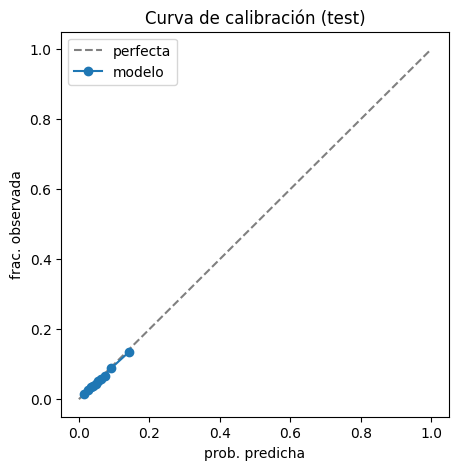

In [11]:
best = dict(study.best_params); best.update(scale_pos_weight=spw,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

gbm = lgb.LGBMClassifier(**best)
# Calibración con CV interna sobre el train completo
modelo = CalibratedClassifierCV(gbm, method="isotonic", cv=3)
modelo.fit(X_train, y_train)

p_test = modelo.predict_proba(X_test)[:, 1]
print("PR-AUC (test):", round(average_precision_score(y_test, p_test), 4))
print("Brier (test): ", round(brier_score_loss(y_test, p_test), 4))

# Curva de confiabilidad
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],"--",color="grey",label="perfecta")
plt.plot(mean_pred, frac_pos, "o-", label="modelo")
plt.xlabel("prob. predicha"); plt.ylabel("frac. observada")
plt.title("Curva de calibración (test)"); plt.legend(); plt.show()

## 10. Evaluación en test — con y sin Black Friday

El modelo rinde **algo mejor en BF** (PR-AUC 0.1268) que en días normales (0.1130); BF tiene tasa de compra más alta (0.0613) y calibración ligeramente peor (Brier 0.0559). El desempeño honesto de "régimen normal" es **~0.113**: BF infla ligeramente el global (0.1177). La diferencia no es grande → el modelo generaliza entre ambos regímenes.

| Subconjunto | PR-AUC | Brier | Tasa compra |
|---|---|---|---|
| Test completo | 0.1177 | 0.0515 | 0.0560 |
| Test ex-BF | 0.1130 | — | — |
| Solo BF (29–30 nov) | 0.1268 | 0.0559 | 0.0613 |

Test completo      | n=2,743,900 | tasa=0.0560 | PR-AUC=0.1177 | Brier=0.0515
Test SIN BF        | n=1,905,357 | tasa=0.0536 | PR-AUC=0.1130 | Brier=0.0495
Test SOLO BF       | n=  838,543 | tasa=0.0613 | PR-AUC=0.1268 | Brier=0.0559


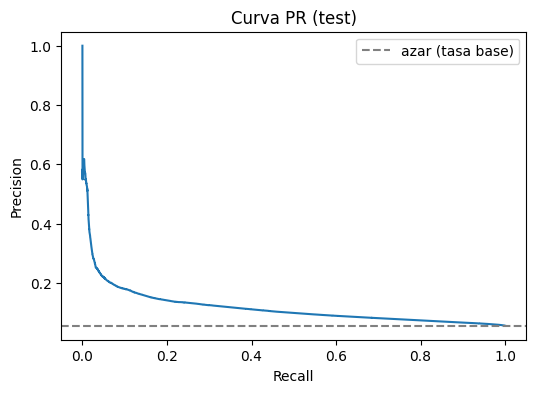

In [12]:
def reporta(nombre, yt, pt):
    print(f"{nombre:18s} | n={len(yt):>9,} | tasa={yt.mean():.4f} | "
          f"PR-AUC={average_precision_score(yt, pt):.4f} | Brier={brier_score_loss(yt, pt):.4f}")

reporta("Test completo", y_test, p_test)
reporta("Test SIN BF", y_test[~bf_window], p_test[~bf_window])
reporta("Test SOLO BF", y_test[bf_window],  p_test[bf_window])

# Curva PR del test completo
prec, rec, _ = precision_recall_curve(y_test, p_test)
plt.figure(figsize=(6,4))
plt.plot(rec, prec); plt.axhline(y_test.mean(), ls="--", color="grey", label="azar (tasa base)")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Curva PR (test)"); plt.legend(); plt.show()

## 11. Umbral operativo (no 0.5)

El modelo entrega probabilidad continua; el **corte es decisión de negocio**, no 0.5. En la gráfica: a medida que subes el umbral, la precisión sube pero el recall baja.

> Si intervenir es barato (un email, un banner) → umbral bajo, capturas más compradores con menor precisión. Si la intervención es costosa (un cupón, un agente) → umbral alto, solo los más probables. El valor óptimo depende del costo de la intervención vs. el valor de una compra capturada.

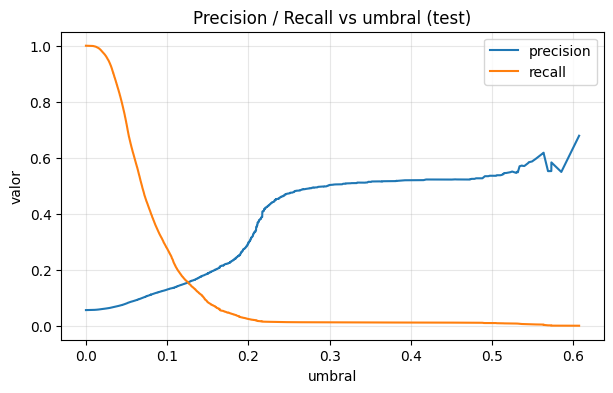

Elige el umbral según el costo del error, NO 0.5. Ej.: si intervenir es barato → umbral bajo (más recall).


In [13]:
prec, rec, thr = precision_recall_curve(y_test, p_test)
plt.figure(figsize=(7,4))
plt.plot(thr, prec[:-1], label="precision")
plt.plot(thr, rec[:-1],  label="recall")
plt.xlabel("umbral"); plt.ylabel("valor"); plt.title("Precision / Recall vs umbral (test)")
plt.legend(); plt.grid(alpha=.3); plt.show()
print("Elige el umbral según el costo del error, NO 0.5. "
      "Ej.: si intervenir es barato → umbral bajo (más recall).")

## 12. Diagnóstico — importancia por permutación

Las features que más mueven la predicción son **`max_price_viewed` (+0.030)**, **`electronics_view_share` (+0.027)** y **`avg_price_viewed` (+0.015)**. Lo que predice la compra es el **nivel de precio y el foco en electrónica**, no cuánto navega la persona. El modelo redescubrió por su cuenta el hallazgo del EDA (el dinero está en electrónica de alto valor).

El engagement (`total_views`, `revisit_intensity`) aporta de forma moderada. `sin_navegacion_previa` aporta exactamente −0.0000 → ese flag no agrega poder predictivo; puedes quitarlo sin costo medible en PR-AUC.

In [14]:
# Permutación sobre una muestra del test (es costosa); usa el GBM ya calibrado
_sample_idx = X_test.sample(min(50000, len(X_test)), random_state=RANDOM_STATE).index
imp = permutation_importance(modelo, X_test.loc[_sample_idx], y_test.loc[_sample_idx],
                             scoring="average_precision", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
orden = np.argsort(imp.importances_mean)[::-1]
for i in orden:
    print(f"{FEATURES[i]:28s} {imp.importances_mean[i]:+.4f} ± {imp.importances_std[i]:.4f}")

max_price_viewed             +0.0301 ± 0.0007
electronics_view_share       +0.0271 ± 0.0019
avg_price_viewed             +0.0149 ± 0.0010
total_views                  +0.0112 ± 0.0005
revisit_intensity            +0.0082 ± 0.0015
views_per_minute             +0.0073 ± 0.0007
distinct_products_viewed     +0.0067 ± 0.0011
avg_inter_event_sec          +0.0065 ± 0.0016
hour_sin                     +0.0060 ± 0.0012
browsing_duration_sec        +0.0055 ± 0.0015
hour_cos                     +0.0022 ± 0.0002
categories_explored_cid      +0.0015 ± 0.0008
brands_compared              +0.0006 ± 0.0006
categories_explored          +0.0003 ± 0.0001
day_of_week                  +0.0003 ± 0.0004
is_weekend                   +0.0002 ± 0.0001
sin_navegacion_previa        -0.0000 ± 0.0000
